#Fourier Transform & Spectrogram

The Fourier transform is a mathematical tool that decomposes a function into a sum of sine and cosine functions. In essence, it converts a function from the time domain to the frequency domain, allowing us to analyze the frequency content of the function.

**Continuous Fourier Transform**

For a continuous function f(t), the Fourier transform is defined as:

$
F(\omega) = \int_{-\infty}^{\infty} f(t) e^{-i\omega t} dt
$

Where:

f(t) is the original function in the time domain

F(ω) is the Fourier transform in the frequency domain

ω is the angular frequency

The inverse Fourier transform can be used to reconstruct the original function from its Fourier transform:

$
f(t) = \frac{1}{2\pi} \int_{-\infty}^{\infty} F(\omega) e^{i\omega t} d\omega
$

**Discrete Fourier Transform (DFT)**

For discrete data points f(n), the DFT is defined as:

$
F(k) = \sum_{n=0}^{N-1} f(n) e^{-i\frac{2\pi k n}{N}}
$

Where:

N is the number of data points
k is the frequency index
The inverse DFT is given by:

$
f(n) = \frac{1}{N} \sum_{k=0}^{N-1} F(k) e^{i\frac{2\pi k n}{N}}
$

In [ ]:
import numpy as np
from scipy.fftpack import fft #fast fourier transform
from scipy.io import wavfile #read and write soundfile
import matplotlib.pyplot as plt
from IPython.display import Audio #play file sound in colab

###1) FFT on Beats

In [ ]:
def sound(f1, f2, t):   # define sound signal function
    return np.sin(2*np.pi*f1*t)+np.sin(2*np.pi*f2*t)

f1, f2 = 300, 302
rate = 10000; L = 8.0   # sample rate & time domain length (s)
t = np.arange( 0, L, float(1.0/rate) )   # time domain array
Audio(data=sound(f1, f2, t),rate=rate) # output the sound to a file

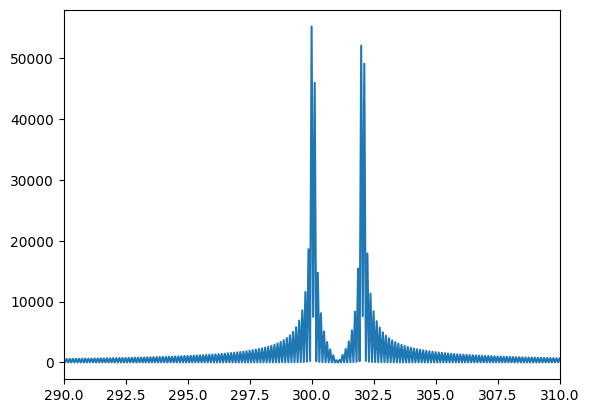

In [ ]:
FT = np.fabs(np.fft.hfft( sound( f1, f2, t[:] ) ))

f = np.arange( 1/(2*L), (len(FT)+1)/(2*L), 1/(2*L) )
plt.xlim((290,310))
plt.plot( f[0:20000],FT[0:20000] )

###2) FFT on Music

In [ ]:
# Downloading files
!gdown --id 1ynN-g89A8vf_9oywhCZt31MdDVHTDieH
!gdown --id 1p34jWsq7Kc4jShf-shr5utEnJaJANI8O
!gdown --id 1urnz3TJ0mStG2QA2eDm_XjZAoXYJxgYN
!gdown --id 1od8wOzKHvCGFNP-k_ipaIsOjC7OEwUr7
!gdown --id 18gfe-EfEmND9TzA9hP1i7MAZaIkmIJ_E
!gdown --id 15-D-cejPCbR_lUDVbn10L2JI2Emfu058

/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1ynN-g89A8vf_9oywhCZt31MdDVHTDieH
To: /content/01-do.wav
100% 293k/293k [00:00<00:00, 56.7MB/s]
/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1p34jWsq7Kc4jShf-shr5utEnJaJANI8O
To: /content/02-re.wav
100% 266k/266k [00:00<00:00, 43.6MB/s]
/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google

<ipython-input-45-27b0cc3e6807>:1: WavFileWarning: Chunk (non-data) not understood, skipping it.
  wavdat = wavfile.read('01-do.wav')


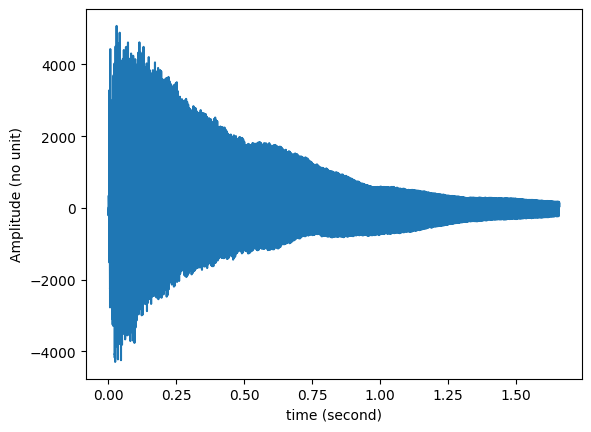

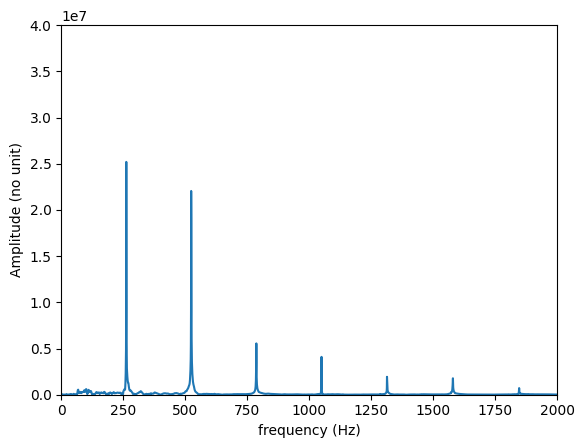

In [ ]:
wavdat = wavfile.read('01-do.wav')
rate = wavdat[0]
num = len(wavdat[1])
T_all = num/float(rate)
A = wavdat[1][:,0]
t = np.linspace( 1/float(rate), T_all, num=num )

plt.xlabel( 'time (second)' )
plt.ylabel( 'Amplitude (no unit)' )
plt.plot( t, A )
plt.show()

FT = fft( A )
f = np.linspace( 1/(T_all), num/(T_all), num=num )

plt.xlim( 0, 2000 )
plt.ylim( 0, 4e7 )
plt.xlabel( 'frequency (Hz)' )
plt.ylabel( 'Amplitude (no unit)' )
plt.plot( f, np.abs( FT ) )
plt.show()


###3) Spectogram

**A spectrogram is a visual representation of the frequency content of a signal over time.**

It's essentially a 2D plot where:

**X-axis:** Represents time.

**Y-axis:** Represents frequency.

**Color/Brightness:** Indicates the amplitude (or intensity) of a particular frequency at a given time.

Think of it as a series of frequency spectra stacked side-by-side, each representing the frequency content of a small segment of the signal. This allows us to see how the frequency composition of the signal changes over time.

**Common uses of spectrograms:**

**Audio analysis:** To visualize the frequency content of sound signals, which is useful in music, speech recognition, and audio engineering.

**Signal processing:** To analyze various types of signals, such as radar, sonar, and biomedical signals.

**Geophysics:** To study seismic data and identify different types of seismic events.
Spectrograms are often used to identify patterns, trends, and anomalies in signals that might be difficult to detect by simply looking at the raw data.

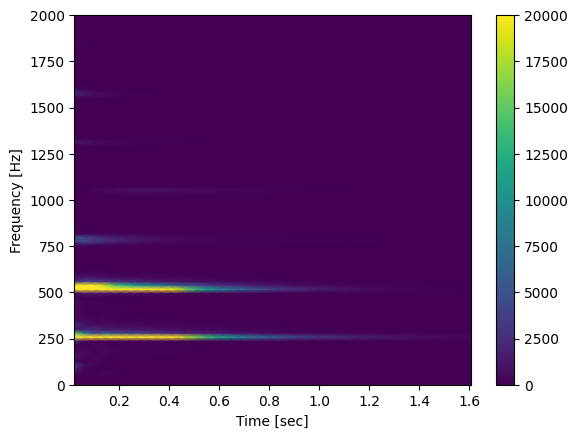

In [ ]:
# prompt: please plot a spectogram of the '01-do.wav' file.

from scipy import signal
f, t, Sxx = signal.spectrogram(A, rate, nperseg=2048)
plt.pcolormesh(t, f, Sxx, shading='gouraud')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.ylim(0,2000)
plt.colorbar()
plt.clim(0,20000)
plt.show()


In [ ]:
!pip install librosa

In [ ]:
def create_waveplot(data, sr):
    plt.figure(figsize=(10, 3))
    plt.title(f'Waveplot for audio', size=15)
    librosa.display.waveshow(data, sr=sr)
    plt.show()

In [ ]:
path = 'DC_a01.wav'
data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate)
Audio(path)

##Tasks

Try create spectrogram of voices and try to detect difference by yourselves